# 🧠 TP Régularisation — Deep Learning

## Objectifs
- Comprendre l'**overfitting** et l'**underfitting**
- Comparer des modèles de tailles différentes (petit, original, grand)
- Appliquer la **régularisation L2** (weight decay)
- Appliquer le **Dropout**
- Utiliser le **Early Stopping**
- Appliquer la **K-Fold Cross Validation** sur le dataset Boston Housing

---

# PARTIE 1 — Classification IMDB (Sentiment Analysis)

## Exercice 1 — Chargement du dataset IMDB

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from keras.datasets import imdb
from keras import models, layers, regularizers

# Chargement du dataset IMDB (top 10000 mots les plus fréquents)
num_words = 10000
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=num_words)

print("=== Dataset IMDB ===")
print(f"Train samples : {len(train_data)}")
print(f"Test samples  : {len(test_data)}")
print(f"Type train_data : {type(train_data)}")
print(f"Exemple train_data[0] (premiers 10 indices) : {train_data[0][:10]}")
print(f"Label correspondant : {train_labels[0]}  (0=négatif, 1=positif)")
print(f"Longueur de la 1ère review : {len(train_data[0])} mots")

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
=== Dataset IMDB ===
Train samples : 25000
Test samples  : 25000
Type train_data : <class 'numpy.ndarray'>
Exemple train_data[0] (premiers 10 indices) : [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65]
Label correspondant : 1  (0=négatif, 1=positif)
Longueur de la 1ère review : 218 mots


**Analyse :** Le dataset IMDB contient 25 000 reviews d'entraînement et 25 000 de test. Chaque review est encodée comme une séquence d'entiers (indices de mots). Les labels sont binaires : 0 (négatif) ou 1 (positif).

## Exercice 2 — Vectorisation des données (One-Hot Encoding)

In [ ]:
def vectorize_sequences(sequences, dimension=10000):
    """Transforme chaque séquence en vecteur binaire de taille 'dimension'.
    Si le mot d'indice i est présent dans la review, results[i] = 1."""
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.
    return results

# Vectorisation
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

# Conversion des labels
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

print("=== Après vectorisation ===")
print(f"x_train shape : {x_train.shape}")  # (25000, 10000)
print(f"x_test shape  : {x_test.shape}")   # (25000, 10000)
print(f"y_train shape : {y_train.shape}")
print(f"y_test shape  : {y_test.shape}")
print(f"\nExemple x_train[0][:20] : {x_train[0][:20]}")
print(f"Somme x_train[0] (nb mots uniques dans la review) : {int(x_train[0].sum())}")

=== Après vectorisation ===
x_train shape : (25000, 10000)
x_test shape  : (25000, 10000)
y_train shape : (25000,)
y_test shape  : (25000,)

Exemple x_train[0][:20] : [0. 1. 1. 0. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1.]
Somme x_train[0] (nb mots uniques dans la review) : 120


**Analyse :** Avant vectorisation, chaque review avait une longueur variable (liste d'entiers). Après vectorisation, chaque review est un vecteur de taille fixe 10 000 (one-hot multi-hot). Cela permet de les passer dans un réseau dense.

---
## Exercice 3 — Modèle Original (2 couches de 16 unités)

In [ ]:
def build_original_model():
    model = models.Sequential([
        layers.Dense(16, activation='relu', input_shape=(10000,)),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='rmsprop',
                  loss='binary_crossentropy',
                  metrics=['acc'])
    return model

original_model = build_original_model()
original_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

## Exercice 4 — Modèle Plus Petit (2 couches de 4 unités)

In [ ]:
def build_smaller_model():
    model = models.Sequential([
        layers.Dense(4, activation='relu', input_shape=(10000,)),
        layers.Dense(4, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='rmsprop',
                  loss='binary_crossentropy',
                  metrics=['acc'])
    return model

smaller_model = build_smaller_model()
smaller_model.summary()

print(f"\nParamètres Original : {original_model.count_params()}")
print(f"Paramètres Smaller  : {smaller_model.count_params()}")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 4)              │        40,004 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,029 (156.36 KB)

 Trainable params: 40,029 (156.36 KB)

 Non-trainable params: 0 (0.00 B)


Paramètres Original : 160305
Paramètres Smaller  : 40029


**Analyse :** Le modèle original a ~160 000 paramètres vs ~40 000 pour le petit modèle. Moins de paramètres = moins de capacité de mémorisation = potentiellement moins d'overfitting.

## Exercices 5 & 6 — Entraînement des deux modèles

In [ ]:
# Entraînement du modèle original
original_hist = original_model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_test, y_test),
    verbose=1
)

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 105ms/step - acc: 0.7290 - loss: 0.5589 - val_acc: 0.8820 - val_loss: 0.3255
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - acc: 0.9016 - loss: 0.2757 - val_acc: 0.8617 - val_loss: 0.3318
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - acc: 0.9189 - loss: 0.2173 - val_acc: 0.8835 - val_loss: 0.2890
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - acc: 0.9376 - loss: 0.1709 - val_acc: 0.8844 - val_loss: 0.2900
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - acc: 0.9466 - loss: 0.1508 - val_acc: 0.8794 - val_loss: 0.3105
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - acc: 0.9525 - loss: 0.1329 - val_acc: 0.8706 - val_loss: 0.3434
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - acc: 0.9565 - loss: 0.1233 - val_acc: 0.8731 - val_loss: 0.3439
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - acc: 0.9647 - loss: 0.1033 - val_acc: 0.8719 - val_loss: 0.3586
Epoch 9/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.968

In [ ]:
# Entraînement du modèle plus petit
smaller_hist = smaller_model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_test, y_test),
    verbose=1
)

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - acc: 0.6257 - loss: 0.6305 - val_acc: 0.8002 - val_loss: 0.5355
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - acc: 0.8372 - loss: 0.4999 - val_acc: 0.8558 - val_loss: 0.4762
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.8924 - loss: 0.4336 - val_acc: 0.8627 - val_loss: 0.4363
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - acc: 0.9140 - loss: 0.3843 - val_acc: 0.8736 - val_loss: 0.3977
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.9311 - loss: 0.3290 - val_acc: 0.8876 - val_loss: 0.3282
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - acc: 0.9363 - loss: 0.2442 - val_acc: 0.8866 - val_loss: 0.2922
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.9427 - loss: 0.1970 - val_acc: 0.8834 - val_loss: 0.2901
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - acc: 0.9487 - loss: 0.1716 - val_acc: 0.8847 - val_loss: 0.2868
Epoch 9/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - acc: 0.9509

## Exercices 7 & 8 — Comparaison Validation Loss (Original vs Smaller)

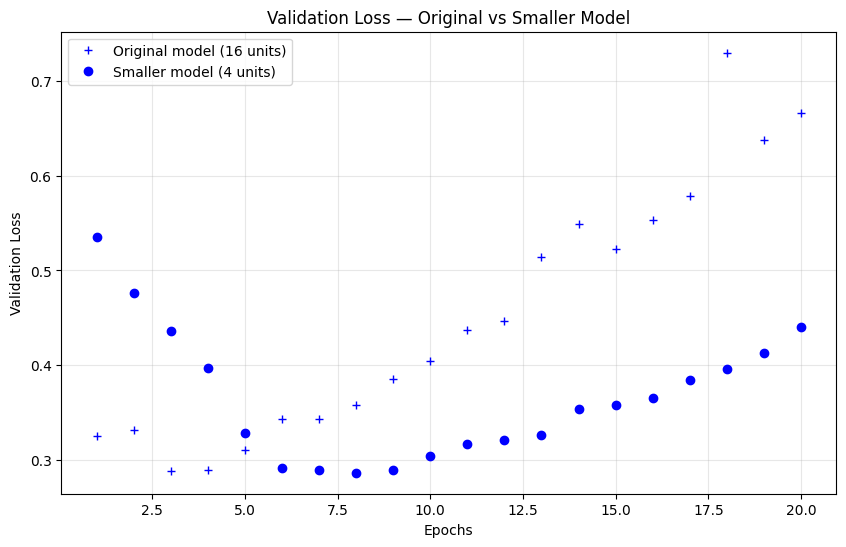


📊 Original model : meilleure val_loss à l'epoch 3 → overfitting après
📊 Smaller model  : meilleure val_loss à l'epoch 8 → overfitting après


In [ ]:
# Extraction des val_loss
original_val_loss = original_hist.history['val_loss']
smaller_val_loss = smaller_hist.history['val_loss']
epochs = range(1, 21)

plt.figure(figsize=(10, 6))
plt.plot(epochs, original_val_loss, 'b+', label='Original model (16 units)')
plt.plot(epochs, smaller_val_loss, 'bo', label='Smaller model (4 units)')
plt.title('Validation Loss — Original vs Smaller Model')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Détection de l'epoch d'overfitting
orig_best_epoch = np.argmin(original_val_loss) + 1
small_best_epoch = np.argmin(smaller_val_loss) + 1
print(f"\n📊 Original model : meilleure val_loss à l'epoch {orig_best_epoch} → overfitting après")
print(f"📊 Smaller model  : meilleure val_loss à l'epoch {small_best_epoch} → overfitting après")

**Analyse :**
- Le modèle **original** (16 unités) commence à overfitter plus tôt (typiquement autour de l'epoch 3-4).
- Le modèle **plus petit** (4 unités) overfitte plus tard et de manière moins sévère.
- **Conclusion** : réduire la taille du réseau est une forme de régularisation implicite.

---
## Exercices 9 & 10 — Modèle Plus Grand (512 unités)

In [ ]:
def build_bigger_model():
    model = models.Sequential([
        layers.Dense(512, activation='relu', input_shape=(10000,)),
        layers.Dense(512, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='rmsprop',
                  loss='binary_crossentropy',
                  metrics=['acc'])
    return model

bigger_model = build_bigger_model()
bigger_model.summary()

print(f"\nParamètres Smaller  : {smaller_model.count_params()}")
print(f"Paramètres Original : {original_model.count_params()}")
print(f"Paramètres Bigger   : {bigger_model.count_params()}")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 512)            │     5,120,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,383,681 (20.54 MB)

 Trainable params: 5,383,681 (20.54 MB)

 Non-trainable params: 0 (0.00 B)


Paramètres Smaller  : 40029
Paramètres Original : 160305
Paramètres Bigger   : 5383681


In [ ]:
bigger_hist = bigger_model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_test, y_test),
    verbose=1
)

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 112ms/step - acc: 0.6848 - loss: 0.5897 - val_acc: 0.8754 - val_loss: 0.3031
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - acc: 0.8814 - loss: 0.2932 - val_acc: 0.8890 - val_loss: 0.2684
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - acc: 0.9147 - loss: 0.2163 - val_acc: 0.8485 - val_loss: 0.3723
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - acc: 0.9226 - loss: 0.1886 - val_acc: 0.8542 - val_loss: 0.3792
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - acc: 0.9471 - loss: 0.1351 - val_acc: 0.8533 - val_loss: 0.4047
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - acc: 0.9682 - loss: 0.0912 - val_acc: 0.8406 - val_loss: 0.5285
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - acc: 0.9670 - loss: 0.0919 - val_acc: 0.8818 - val_loss: 0.3952
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - acc: 0.9902 - loss: 0.0363 - val_acc: 0.8801 - val_loss: 0.4487
Epoch 9/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - acc: 0.994

## Exercice 11 — Comparaison Validation Loss (Original vs Bigger)

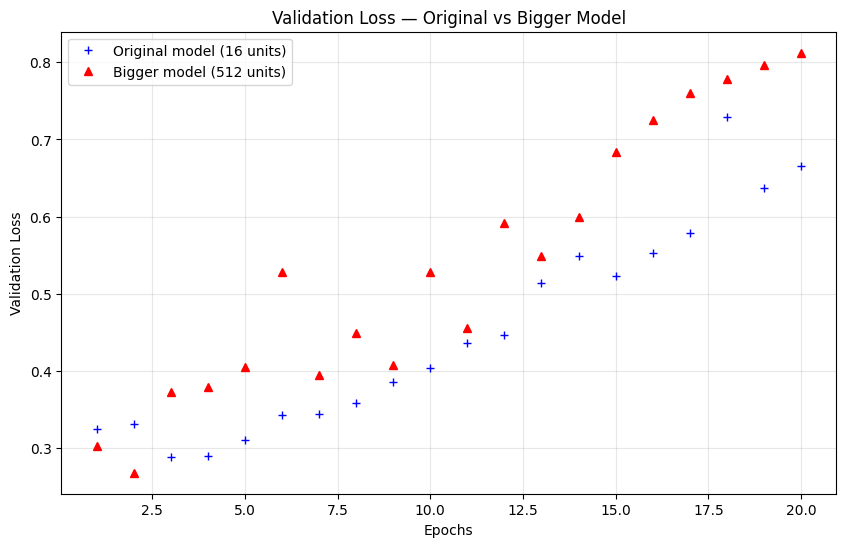


📊 Original : overfitting après epoch 3
📊 Bigger   : overfitting après epoch 2


In [ ]:
bigger_val_loss = bigger_hist.history['val_loss']

plt.figure(figsize=(10, 6))
plt.plot(epochs, original_val_loss, 'b+', label='Original model (16 units)')
plt.plot(epochs, bigger_val_loss, 'r^', label='Bigger model (512 units)')
plt.title('Validation Loss — Original vs Bigger Model')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

big_best_epoch = np.argmin(bigger_val_loss) + 1
print(f"\n📊 Original : overfitting après epoch {orig_best_epoch}")
print(f"📊 Bigger   : overfitting après epoch {big_best_epoch}")

**Analyse :**
- Le modèle **bigger** (512 unités) overfitte **beaucoup plus vite** et **plus sévèrement** que l'original.
- Sa val_loss explose rapidement car il a la capacité de mémoriser le training set presque parfaitement.
- **Plus de capacité → convergence rapide vers 0 sur le train → overfitting massif.**

## 📊 Récapitulatif — Comparaison des 3 modèles

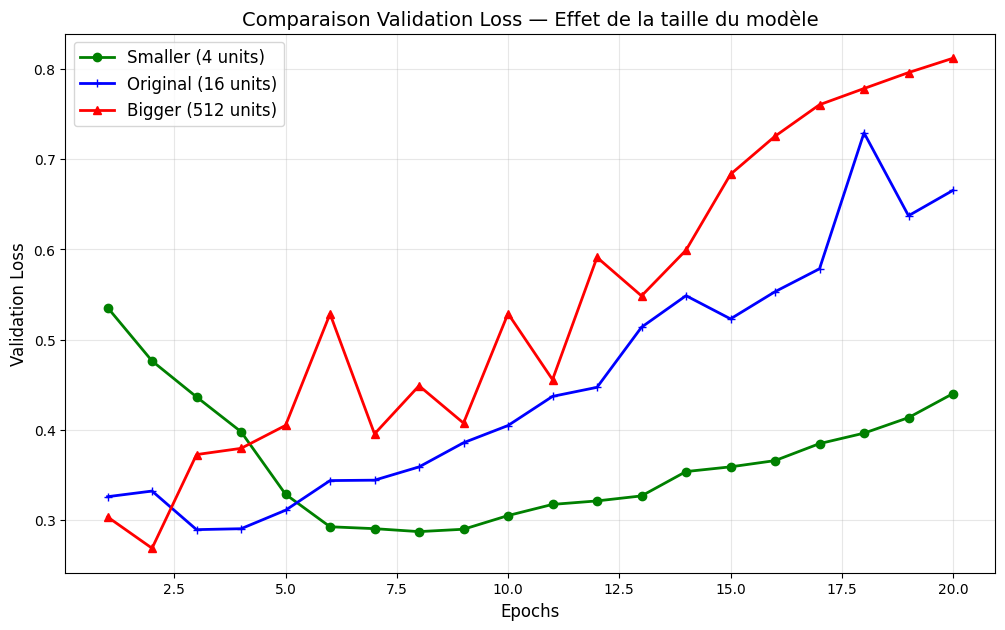

In [ ]:
plt.figure(figsize=(12, 7))
plt.plot(epochs, smaller_val_loss, 'go-', label='Smaller (4 units)', linewidth=2)
plt.plot(epochs, original_val_loss, 'b+-', label='Original (16 units)', linewidth=2)
plt.plot(epochs, bigger_val_loss, 'r^-', label='Bigger (512 units)', linewidth=2)
plt.title('Comparaison Validation Loss — Effet de la taille du modèle', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Validation Loss', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

---
# Régularisation L2 (Weight Decay)

## Exercice 12 — Modèle avec régularisation L2

In [ ]:
def build_l2_model():
    """Modèle identique à l'original mais avec régularisation L2 sur les 2 premières couches.
    L2(0.001) signifie : on ajoute 0.001 * sum(w²) à la loss pour chaque couche.
    Cela pénalise les grands poids et force le modèle à garder des poids petits."""
    model = models.Sequential([
        layers.Dense(16, activation='relu', input_shape=(10000,),
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(16, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='rmsprop',
                  loss='binary_crossentropy',
                  metrics=['acc'])
    return model

l2_model = build_l2_model()
l2_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

## Exercice 13 — Entraînement du modèle L2

In [ ]:
l2_hist = l2_model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_test, y_test),
    verbose=1
)

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 112ms/step - acc: 0.7422 - loss: 0.6005 - val_acc: 0.8718 - val_loss: 0.3901
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - acc: 0.8962 - loss: 0.3348 - val_acc: 0.8881 - val_loss: 0.3354
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - acc: 0.9201 - loss: 0.2704 - val_acc: 0.8866 - val_loss: 0.3317
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - acc: 0.9328 - loss: 0.2416 - val_acc: 0.8824 - val_loss: 0.3407
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.9346 - loss: 0.2324 - val_acc: 0.8829 - val_loss: 0.3401
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.9453 - loss: 0.2131 - val_acc: 0.8822 - val_loss: 0.3473
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - acc: 0.9453 - loss: 0.2085 - val_acc: 0.8674 - val_loss: 0.3924
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - acc: 0.9476 - loss: 0.2034 - val_acc: 0.8793 - val_loss: 0.3621
Epoch 9/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - acc: 0.952

## Exercice 14 — Comparaison Original vs L2

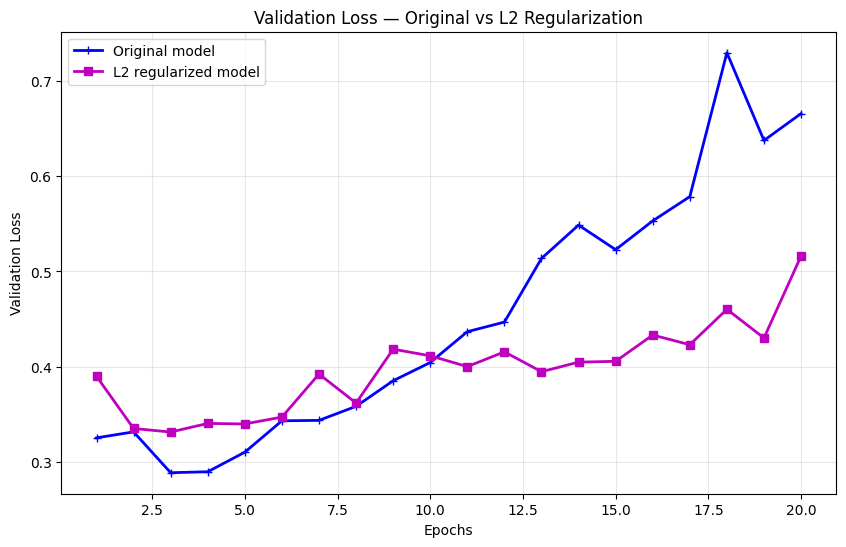

📊 Original : min val_loss = 0.2890 à epoch 3
📊 L2 model : min val_loss = 0.3317 à epoch 3


In [ ]:
l2_val_loss = l2_hist.history['val_loss']

plt.figure(figsize=(10, 6))
plt.plot(epochs, original_val_loss, 'b+-', label='Original model', linewidth=2)
plt.plot(epochs, l2_val_loss, 'ms-', label='L2 regularized model', linewidth=2)
plt.title('Validation Loss — Original vs L2 Regularization')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

l2_best_epoch = np.argmin(l2_val_loss) + 1
print(f"📊 Original : min val_loss = {min(original_val_loss):.4f} à epoch {orig_best_epoch}")
print(f"📊 L2 model : min val_loss = {min(l2_val_loss):.4f} à epoch {l2_best_epoch}")

**Analyse :**
- Le modèle **L2** est plus résistant à l'overfitting : sa val_loss monte plus lentement.
- Les deux modèles ont le **même nombre de paramètres**, mais L2 contraint les poids à rester petits.
- La **pénalité L2** agit comme un régulateur : le modèle apprend des représentations plus simples et plus généralisables.

---
## Bonus — Régularisation L1 et L1+L2

In [ ]:
# Modèle avec L1 regularization
def build_l1_model():
    model = models.Sequential([
        layers.Dense(16, activation='relu', input_shape=(10000,),
                     kernel_regularizer=regularizers.l1(0.001)),
        layers.Dense(16, activation='relu',
                     kernel_regularizer=regularizers.l1(0.001)),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
    return model

# Modèle avec L1+L2 regularization
def build_l1_l2_model():
    model = models.Sequential([
        layers.Dense(16, activation='relu', input_shape=(10000,),
                     kernel_regularizer=regularizers.l1_l2(l1=0.001, l2=0.001)),
        layers.Dense(16, activation='relu',
                     kernel_regularizer=regularizers.l1_l2(l1=0.001, l2=0.001)),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
    return model

l1_model = build_l1_model()
l1_l2_model = build_l1_l2_model()

l1_hist = l1_model.fit(x_train, y_train, epochs=20, batch_size=512,
                        validation_data=(x_test, y_test), verbose=0)
l1_l2_hist = l1_l2_model.fit(x_train, y_train, epochs=20, batch_size=512,
                              validation_data=(x_test, y_test), verbose=0)

print("Entraînement L1 et L1+L2 terminé !")

Entraînement L1 et L1+L2 terminé !


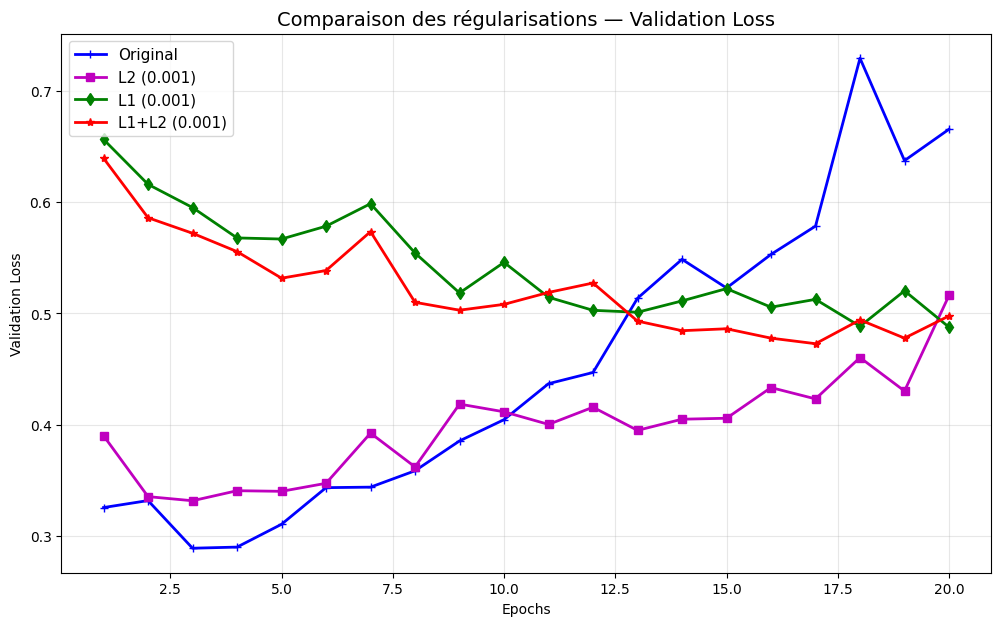

In [ ]:
l1_val_loss = l1_hist.history['val_loss']
l1_l2_val_loss = l1_l2_hist.history['val_loss']

plt.figure(figsize=(12, 7))
plt.plot(epochs, original_val_loss, 'b+-', label='Original', linewidth=2)
plt.plot(epochs, l2_val_loss, 'ms-', label='L2 (0.001)', linewidth=2)
plt.plot(epochs, l1_val_loss, 'gd-', label='L1 (0.001)', linewidth=2)
plt.plot(epochs, l1_l2_val_loss, 'r*-', label='L1+L2 (0.001)', linewidth=2)
plt.title('Comparaison des régularisations — Validation Loss', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

**Analyse L1 vs L2 vs L1+L2 :**
- **L1** pousse les poids vers exactement 0 → crée de la **sparsité** (certains poids deviennent nuls).
- **L2** pousse les poids vers des valeurs petites mais non nulles → distribution plus "régulière".
- **L1+L2** combine les deux effets.
- En pratique, L2 est souvent préférée pour les réseaux de neurones.

---
# Dropout

## Exercice 15 — Modèle avec Dropout

In [ ]:
def build_dropout_model():
    """Modèle original + Dropout(0.5) après chaque couche cachée.
    Dropout désactive aléatoirement 50% des neurones pendant l'entraînement,
    ce qui empêche le réseau de trop dépendre de neurones spécifiques."""
    model = models.Sequential([
        layers.Dense(16, activation='relu', input_shape=(10000,)),
        layers.Dropout(0.5),
        layers.Dense(16, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='rmsprop',
                  loss='binary_crossentropy',
                  metrics=['acc'])
    return model

dpt_model = build_dropout_model()
dpt_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

## Exercice 16 — Entraînement du modèle Dropout

In [ ]:
dpt_hist = dpt_model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_test, y_test),
    verbose=1
)

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - acc: 0.5997 - loss: 0.6513 - val_acc: 0.8306 - val_loss: 0.5172
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - acc: 0.7891 - loss: 0.5162 - val_acc: 0.8733 - val_loss: 0.3956
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - acc: 0.8521 - loss: 0.4152 - val_acc: 0.8859 - val_loss: 0.3358
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - acc: 0.8842 - loss: 0.3521 - val_acc: 0.8882 - val_loss: 0.3006
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.9076 - loss: 0.2996 - val_acc: 0.8875 - val_loss: 0.2928
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - acc: 0.9141 - loss: 0.2734 - val_acc: 0.8852 - val_loss: 0.2862
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - acc: 0.9247 - loss: 0.2426 - val_acc: 0.8852 - val_loss: 0.3044
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - acc: 0.9313 - loss: 0.2197 - val_acc: 0.8853 - val_loss: 0.3154
Epoch 9/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - acc: 0.939

## Exercice 17 — Comparaison Original vs Dropout

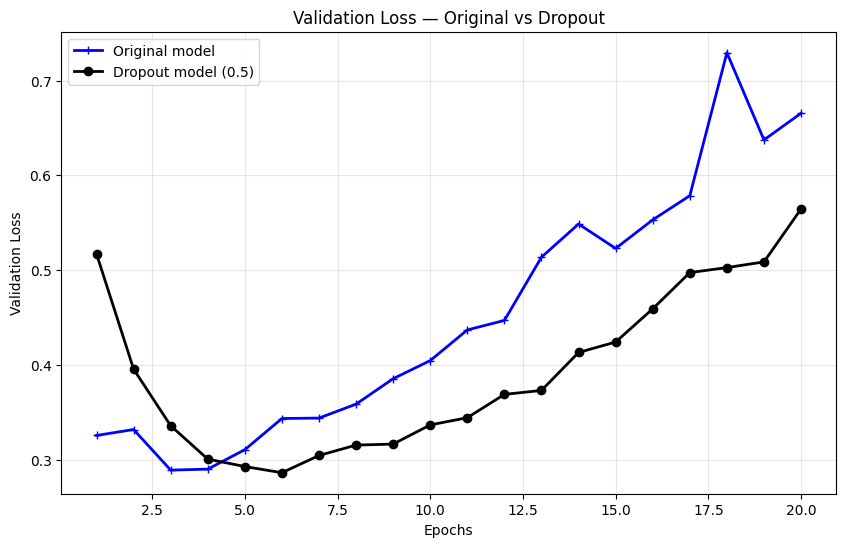

📊 Original : min val_loss = 0.2890 à epoch 3
📊 Dropout  : min val_loss = 0.2862 à epoch 6


In [ ]:
dpt_val_loss = dpt_hist.history['val_loss']

plt.figure(figsize=(10, 6))
plt.plot(epochs, original_val_loss, 'b+-', label='Original model', linewidth=2)
plt.plot(epochs, dpt_val_loss, 'ko-', label='Dropout model (0.5)', linewidth=2)
plt.title('Validation Loss — Original vs Dropout')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

dpt_best_epoch = np.argmin(dpt_val_loss) + 1
print(f"📊 Original : min val_loss = {min(original_val_loss):.4f} à epoch {orig_best_epoch}")
print(f"📊 Dropout  : min val_loss = {min(dpt_val_loss):.4f} à epoch {dpt_best_epoch}")

**Analyse :**
- Le **Dropout** réduit significativement l'overfitting.
- La val_loss augmente plus lentement et reste plus basse plus longtemps.
- Le Dropout force le réseau à être plus robuste : chaque neurone doit apprendre des features utiles indépendamment.

---
# Augmentation de données texte (Bonus)

## Exercice 18 — Augmentation simple du texte

**Objectif :** comparer **le même modèle avec Dropout** dans deux cas :
1. entraînement sur les données originales
2. entraînement sur des données **augmentées**

Ici, comme les reviews sont ensuite transformées en **vecteurs one-hot / bag-of-words**, une permutation de mots n'aurait **aucun effet** après vectorisation.
On choisit donc une augmentation compatible avec cette représentation :
- **suppression aléatoire** de quelques mots (*word dropout*)
- **remplacement aléatoire** de quelques mots par le token inconnu `<UNK>`

L'idée est de créer des reviews légèrement différentes, mais gardant le **même sentiment global**. Cela agit comme une forme de régularisation par **variété de données**.


In [ ]:
import math
from tensorflow import keras
import numpy as np

rng = np.random.default_rng(42)

def vectorize_sequences(sequences, dimension=10000, dtype="float32"):
    results = np.zeros((len(sequences), dimension), dtype=dtype)
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.
    return results

def augment_sequence(sequence, drop_prob=0.10, unk_prob=0.10, min_len=8):
    augmented = []
    for token in sequence:
        r = rng.random()
        if r < drop_prob:
            continue
        elif r < drop_prob + unk_prob:
            augmented.append(2)   # <UNK>
        else:
            augmented.append(token)

    if len(augmented) < min_len:
        augmented = list(sequence[:min_len])

    return augmented

class AugmentedBoWSequence(keras.utils.Sequence):
    def __init__(self, sequences, labels, batch_size=512, dimension=10000,
                 aug_ratio=0.7, drop_prob=0.10, unk_prob=0.10, shuffle=True):
        self.sequences = sequences
        self.labels = np.asarray(labels, dtype='float32')
        self.batch_size = batch_size
        self.dimension = dimension
        self.aug_ratio = aug_ratio
        self.drop_prob = drop_prob
        self.unk_prob = unk_prob
        self.shuffle = shuffle
        self.indices = np.arange(len(self.sequences))
        self.on_epoch_end()

    def __len__(self):
        return math.ceil(len(self.sequences) / self.batch_size)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, idx):
        batch_ids = self.indices[idx*self.batch_size:(idx+1)*self.batch_size]
        batch_sequences = []

        for i in batch_ids:
            seq = self.sequences[i]
            if rng.random() < self.aug_ratio:
                seq = augment_sequence(
                    seq,
                    drop_prob=self.drop_prob,
                    unk_prob=self.unk_prob
                )
            batch_sequences.append(seq)

        x_batch = vectorize_sequences(
            batch_sequences,
            dimension=self.dimension
        ).astype('float32')

        y_batch = self.labels[batch_ids]
        return x_batch, y_batch

## Exercice 19 — Entraînement du modèle Dropout + augmentation

On garde **exactement la même architecture** que dans la section Dropout.
Ainsi, si les courbes changent, cela vient principalement de **l'augmentation des données**, pas d'un changement de modèle.


In [ ]:
# Re-vectoriser en float32 si nécessaire
x_test = x_test.astype("float32", copy=False)
y_train = np.asarray(train_labels).astype("float32")
y_test = np.asarray(test_labels).astype("float32")

train_aug_sequence = AugmentedBoWSequence(
    train_data,
    train_labels,
    batch_size=512,
    dimension=10000,
    aug_ratio=0.7,
    drop_prob=0.10,
    unk_prob=0.10,
    shuffle=True
)

dpt_aug_model = build_dropout_model()

dpt_aug_hist = dpt_aug_model.fit(
    train_aug_sequence,
    epochs=20,
    validation_data=(x_test, y_test),
    verbose=1
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


49/49 ━━━━━━━━━━━━━━━━━━━━ 12s 211ms/step - acc: 0.6070 - loss: 0.6505 - val_acc: 0.8588 - val_loss: 0.4534
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 125ms/step - acc: 0.7962 - loss: 0.4877 - val_acc: 0.8764 - val_loss: 0.3459
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 119ms/step - acc: 0.8494 - loss: 0.3948 - val_acc: 0.8854 - val_loss: 0.2977
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 138ms/step - acc: 0.8748 - loss: 0.3428 - val_acc: 0.8883 - val_loss: 0.2806
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - acc: 0.8951 - loss: 0.2973 - val_acc: 0.8876 - val_loss: 0.2822
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 136ms/step - acc: 0.9056 - loss: 0.2715 - val_acc: 0.8870 - val_loss: 0.2781
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 120ms/step - acc: 0.9105 - loss: 0.2545 - val_acc: 0.8882 - val_loss: 0.2916
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 152ms/step - acc: 0.9176 - loss: 0.2349 - val_acc: 0.8875 - val_loss: 0.3061
Epoch 9/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 127ms/step - acc: 0.9215

## Exercice 20 — Comparaison Validation Loss : Dropout vs Dropout + augmentation

**Lecture attendue :**
- si la courbe **Dropout + augmentation** reste plus basse, ou remonte plus tard,
  alors l'augmentation aide à **réduire l'overfitting** ;
- si les deux courbes sont très proches, cela signifie que cette augmentation simple
  apporte peu dans ce réglage précis.

En pratique, l'augmentation **ne garantit pas toujours** de supprimer totalement l'overfitting,
mais elle le **réduit souvent** en exposant le modèle à davantage de variantes du même signal.


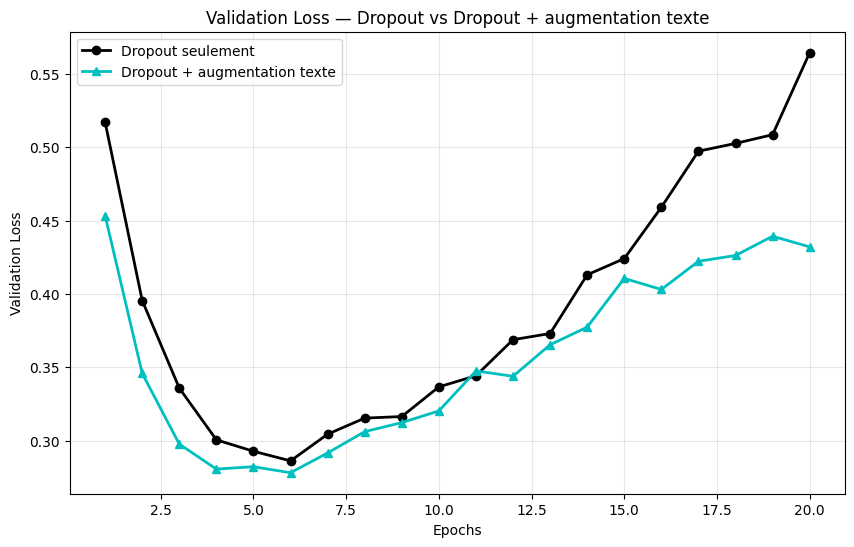

📊 Dropout seul              : min val_loss = 0.2862 à epoch 6
📊 Dropout + augmentation    : min val_loss = 0.2781 à epoch 6
📉 Gain absolu sur la meilleure val_loss : 0.0081
🔎 Gap final (val_loss - train_loss) Dropout seul           : 0.4476
🔎 Gap final (val_loss - train_loss) Dropout + augmentation : 0.2639


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Historique du modèle Dropout seul
dpt_val_loss = dpt_hist.history['val_loss']
dpt_train_loss = dpt_hist.history['loss']

# Historique du modèle Dropout + augmentation
dpt_aug_val_loss = dpt_aug_hist.history['val_loss']
dpt_aug_train_loss = dpt_aug_hist.history['loss']

# Epochs
epochs_dropout = range(1, len(dpt_val_loss) + 1)
epochs_aug = range(1, len(dpt_aug_val_loss) + 1)

# Meilleures epochs
dpt_best_epoch = np.argmin(dpt_val_loss) + 1
dpt_aug_best_epoch = np.argmin(dpt_aug_val_loss) + 1

# Courbe de comparaison
plt.figure(figsize=(10, 6))
plt.plot(epochs_dropout, dpt_val_loss, 'ko-', label='Dropout seulement', linewidth=2)
plt.plot(epochs_aug, dpt_aug_val_loss, 'c^-', label='Dropout + augmentation texte', linewidth=2)
plt.title('Validation Loss — Dropout vs Dropout + augmentation texte')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"📊 Dropout seul              : min val_loss = {min(dpt_val_loss):.4f} à epoch {dpt_best_epoch}")
print(f"📊 Dropout + augmentation    : min val_loss = {min(dpt_aug_val_loss):.4f} à epoch {dpt_aug_best_epoch}")
print(f"📉 Gain absolu sur la meilleure val_loss : {min(dpt_val_loss) - min(dpt_aug_val_loss):.4f}")

# Indicateur simple d’overfitting
final_gap_dropout = dpt_val_loss[-1] - dpt_train_loss[-1]
final_gap_aug = dpt_aug_val_loss[-1] - dpt_aug_train_loss[-1]

print(f"🔎 Gap final (val_loss - train_loss) Dropout seul           : {final_gap_dropout:.4f}")
print(f"🔎 Gap final (val_loss - train_loss) Dropout + augmentation : {final_gap_aug:.4f}")

---
# Early Stopping (Bonus — technique essentielle)

In [ ]:
from keras.callbacks import EarlyStopping, ModelCheckpoint

# Reconstruction du modèle original pour Early Stopping
es_model = build_original_model()

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',   # On surveille la validation loss
    patience=3,           # On attend 3 epochs sans amélioration avant d'arrêter
    restore_best_weights=True  # On restaure les poids du meilleur epoch
)

es_hist = es_model.fit(
    x_train, y_train,
    epochs=50,  # On met beaucoup d'epochs, le early stopping arrêtera avant
    batch_size=512,
    validation_data=(x_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

print(f"\n🛑 Early Stopping : entraînement arrêté à l'epoch {len(es_hist.history['val_loss'])}")
print(f"   Meilleure val_loss : {min(es_hist.history['val_loss']):.4f}")

Epoch 1/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - acc: 0.7396 - loss: 0.5798 - val_acc: 0.8658 - val_loss: 0.3715
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - acc: 0.8946 - loss: 0.3134 - val_acc: 0.8864 - val_loss: 0.2940
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - acc: 0.9179 - loss: 0.2314 - val_acc: 0.8851 - val_loss: 0.2863
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.9309 - loss: 0.1940 - val_acc: 0.8812 - val_loss: 0.2939
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - acc: 0.9389 - loss: 0.1692 - val_acc: 0.8840 - val_loss: 0.2923
Epoch 6/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - acc: 0.9512 - loss: 0.1462 - val_acc: 0.8830 - val_loss: 0.3024

🛑 Early Stopping : entraînement arrêté à l'epoch 6
   Meilleure val_loss : 0.2863


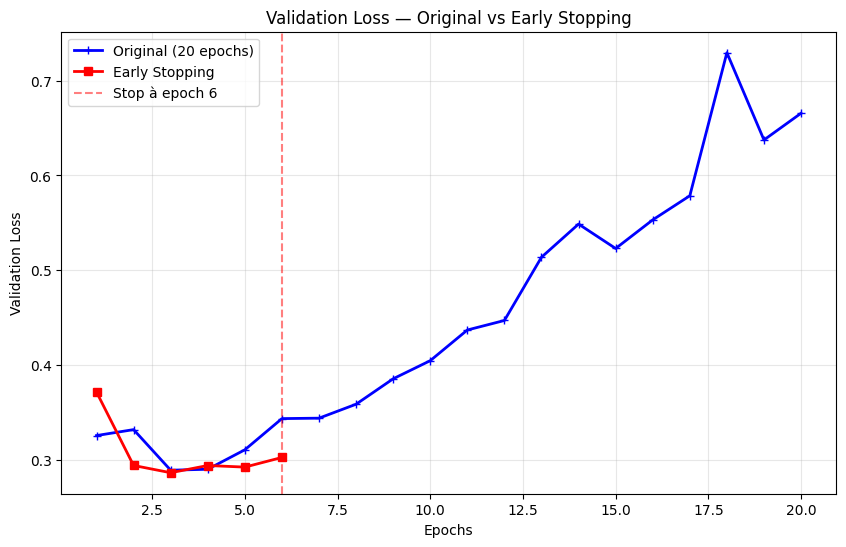

In [ ]:
es_val_loss = es_hist.history['val_loss']
es_epochs = range(1, len(es_val_loss) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, original_val_loss, 'b+-', label='Original (20 epochs)', linewidth=2)
plt.plot(es_epochs, es_val_loss, 'rs-', label='Early Stopping', linewidth=2)
plt.axvline(x=len(es_val_loss), color='r', linestyle='--', alpha=0.5, label=f'Stop à epoch {len(es_val_loss)}')
plt.title('Validation Loss — Original vs Early Stopping')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Analyse Early Stopping :**
- L'entraînement s'arrête automatiquement quand la val_loss ne s'améliore plus pendant `patience` epochs.
- `restore_best_weights=True` récupère les meilleurs poids (pas ceux du dernier epoch).
- C'est une technique **simple et très efficace** pour éviter l'overfitting.

---
## 📊 Récapitulatif Final — Toutes les techniques de régularisation

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


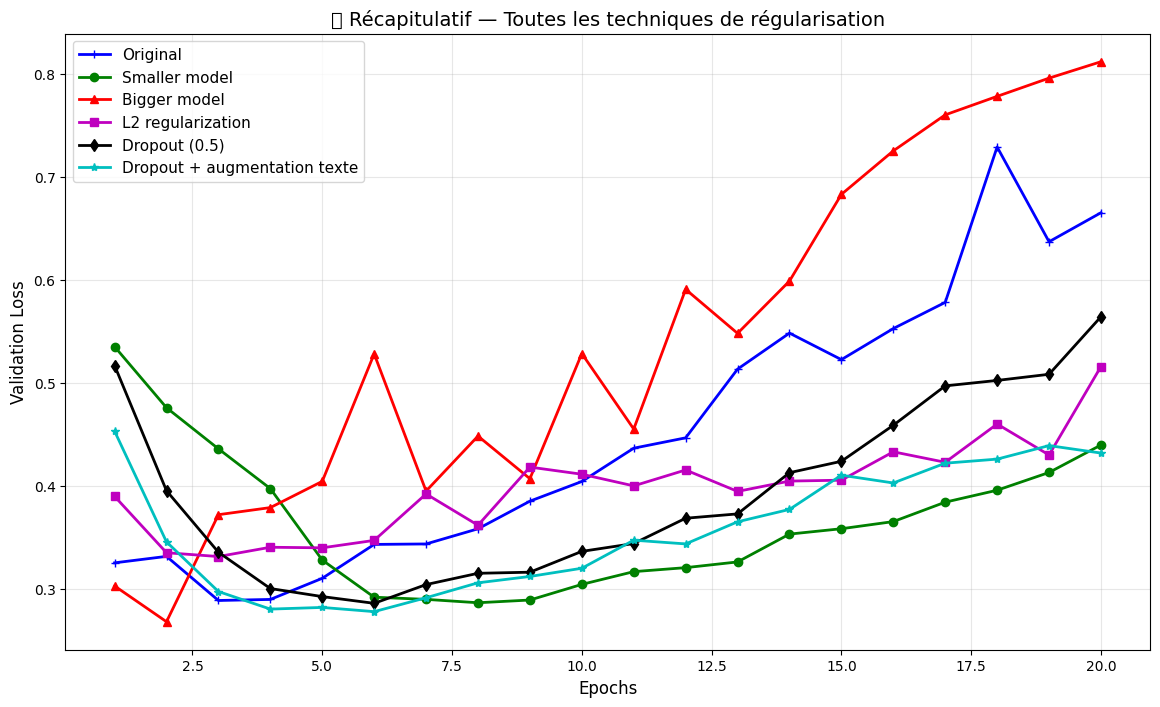


RÉSUMÉ DES TECHNIQUES DE RÉGULARISATION
Technique                        Min Val Loss    Best Epoch  
--------------------------------------------------------------
Smaller model                    0.2868          8           
Original model                   0.2890          3           
Bigger model                     0.2684          2           
L2 regularization                0.3317          3           
Dropout (0.5)                    0.2862          6           
Dropout + augmentation texte     0.2781          6           
Early Stopping                   0.2863          3           


In [ ]:
plt.figure(figsize=(14, 8))
plt.plot(epochs, original_val_loss, 'b+-', label='Original', linewidth=2)
plt.plot(epochs, smaller_val_loss, 'go-', label='Smaller model', linewidth=2)
plt.plot(epochs, bigger_val_loss, 'r^-', label='Bigger model', linewidth=2)
plt.plot(epochs, l2_val_loss, 'ms-', label='L2 regularization', linewidth=2)
plt.plot(epochs, dpt_val_loss, 'kd-', label='Dropout (0.5)', linewidth=2)
plt.plot(epochs, dpt_aug_val_loss, 'c*-', label='Dropout + augmentation texte', linewidth=2)
plt.title('🔍 Récapitulatif — Toutes les techniques de régularisation', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Validation Loss', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

print("\n" + "="*72)
print("RÉSUMÉ DES TECHNIQUES DE RÉGULARISATION")
print("="*72)
print(f"{'Technique':<32} {'Min Val Loss':<15} {'Best Epoch':<12}")
print("-"*62)
print(f"{'Smaller model':<32} {min(smaller_val_loss):<15.4f} {np.argmin(smaller_val_loss)+1:<12}")
print(f"{'Original model':<32} {min(original_val_loss):<15.4f} {np.argmin(original_val_loss)+1:<12}")
print(f"{'Bigger model':<32} {min(bigger_val_loss):<15.4f} {np.argmin(bigger_val_loss)+1:<12}")
print(f"{'L2 regularization':<32} {min(l2_val_loss):<15.4f} {np.argmin(l2_val_loss)+1:<12}")
print(f"{'Dropout (0.5)':<32} {min(dpt_val_loss):<15.4f} {np.argmin(dpt_val_loss)+1:<12}")
print(f"{'Dropout + augmentation texte':<32} {min(dpt_aug_val_loss):<15.4f} {np.argmin(dpt_aug_val_loss)+1:<12}")
print(f"{'Early Stopping':<32} {min(es_val_loss):<15.4f} {np.argmin(es_val_loss)+1:<12}")


---
---
# PARTIE 2 — Régression : Boston Housing (K-Fold Cross Validation)

## Exercice 1 — Chargement du dataset Boston Housing

In [ ]:
from keras.datasets import boston_housing

(train_data, train_targets), (test_data, test_targets) = boston_housing.load_data()

print("=== Dataset Boston Housing ===")
print(f"Train data shape   : {train_data.shape}")    # (404, 13)
print(f"Test data shape    : {test_data.shape}")      # (102, 13)
print(f"Train targets shape: {train_targets.shape}")
print(f"Test targets shape : {test_targets.shape}")
print(f"\nExemple de targets (prix en milliers $) : {train_targets[:10]}")
print(f"Prix min: ${train_targets.min()*1000:.0f}, max: ${train_targets.max()*1000:.0f}, moyen: ${train_targets.mean()*1000:.0f}")

57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
=== Dataset Boston Housing ===
Train data shape   : (404, 13)
Test data shape    : (102, 13)
Train targets shape: (404,)
Test targets shape : (102,)

Exemple de targets (prix en milliers $) : [15.2 42.3 50.  21.1 17.7 18.5 11.3 15.6 15.6 14.4]
Prix min: $5000, max: $50000, moyen: $22395


## Exercice 2 — Normalisation des données

In [ ]:
# Normalisation : x = (x - mean) / std
# IMPORTANT : on utilise la moyenne et l'écart-type du TRAIN set uniquement
mean = train_data.mean(axis=0)
std = train_data.std(axis=0)

train_data = (train_data - mean) / std
test_data = (test_data - mean) / std  # On normalise le test avec les stats du train !

print("Après normalisation :")
print(f"Train mean ≈ 0 : {train_data.mean(axis=0)[:5].round(2)}")
print(f"Train std  ≈ 1 : {train_data.std(axis=0)[:5].round(2)}")

Après normalisation :
Train mean ≈ 0 : [-0.  0.  0. -0. -0.]
Train std  ≈ 1 : [1. 1. 1. 1. 1.]


**Analyse :** La normalisation est essentielle car les features ont des échelles très différentes (taux de criminalité vs nombre de pièces vs taxe). Sans normalisation, le réseau aurait du mal à converger.

## Exercice 3 — Définition du modèle

In [ ]:
def build_model():
    """Petit réseau pour la régression : 2 couches de 64 unités + sortie linéaire.
    - Pas d'activation en sortie (régression libre)
    - Loss = MSE (Mean Squared Error)
    - Métrique = MAE (Mean Absolute Error) → plus interprétable"""
    model = models.Sequential([
        layers.Dense(64, activation='relu', input_shape=(train_data.shape[1],)),
        layers.Dense(64, activation='relu'),
        layers.Dense(1)  # Pas d'activation → sortie linéaire pour régression
    ])
    model.compile(optimizer='rmsprop',
                  loss='mse',
                  metrics=['mae'])
    return model

temp_model = build_model()
temp_model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,121 (20.00 KB)

 Trainable params: 5,121 (20.00 KB)

 Non-trainable params: 0 (0.00 B)

## Exercices 4 & 5 — K-Fold Cross Validation (K=4, 100 epochs)

In [ ]:
k = 4
num_val_samples = len(train_data) // k
num_epochs = 100
all_scores = []

for i in range(k):
    print(f'Processing fold #{i}')

    # Données de validation pour ce fold
    val_data = train_data[i * num_val_samples: (i + 1) * num_val_samples]
    val_targets = train_targets[i * num_val_samples: (i + 1) * num_val_samples]

    # Données d'entraînement (tout sauf le fold de validation)
    partial_train_data = np.concatenate(
        [train_data[:i * num_val_samples], train_data[(i + 1) * num_val_samples:]],
        axis=0)
    partial_train_targets = np.concatenate(
        [train_targets[:i * num_val_samples], train_targets[(i + 1) * num_val_samples:]],
        axis=0)

    # Construction et entraînement
    model = build_model()
    model.fit(partial_train_data, partial_train_targets,
              epochs=num_epochs, batch_size=1, verbose=0)

    # Évaluation
    val_mse, val_mae = model.evaluate(val_data, val_targets, verbose=0)
    all_scores.append(val_mae)

print(f"\n=== Résultats K-Fold (K={k}) ===")
for i, score in enumerate(all_scores):
    print(f"Fold {i} MAE : {score:.2f} (erreur moyenne de ${score*1000:.0f})")
print(f"\nMAE moyenne : {np.mean(all_scores):.2f} (±{np.std(all_scores):.2f})")
print(f"→ En moyenne, le modèle se trompe de ~${np.mean(all_scores)*1000:.0f} sur le prix")

Processing fold #0
Processing fold #1
Processing fold #2
Processing fold #3

=== Résultats K-Fold (K=4) ===
Fold 0 MAE : 2.16 (erreur moyenne de $2158)
Fold 1 MAE : 2.25 (erreur moyenne de $2249)
Fold 2 MAE : 2.96 (erreur moyenne de $2960)
Fold 3 MAE : 2.34 (erreur moyenne de $2338)

MAE moyenne : 2.43 (±0.31)
→ En moyenne, le modèle se trompe de ~$2426 sur le prix


## Exercices 6 & 7 — K-Fold avec 500 epochs (sauvegarde MAE par epoch)

In [ ]:
k = 4
num_val_samples = len(train_data) // k
num_epochs = 500
all_mae_histories = []

for i in range(k):
    print(f'Processing fold #{i}')

    val_data = train_data[i * num_val_samples: (i + 1) * num_val_samples]
    val_targets = train_targets[i * num_val_samples: (i + 1) * num_val_samples]

    partial_train_data = np.concatenate(
        [train_data[:i * num_val_samples], train_data[(i + 1) * num_val_samples:]],
        axis=0)
    partial_train_targets = np.concatenate(
        [train_targets[:i * num_val_samples], train_targets[(i + 1) * num_val_samples:]],
        axis=0)

    model = build_model()
    history = model.fit(partial_train_data, partial_train_targets,
                        validation_data=(val_data, val_targets),
                        epochs=num_epochs, batch_size=1, verbose=0)

    mae_history = history.history['val_mae']
    all_mae_histories.append(mae_history)

# Exercice 7 : Moyenne par epoch sur tous les folds
average_mae_history = [np.mean([x[i] for x in all_mae_histories]) for i in range(num_epochs)]

print(f"\nTerminé ! MAE moyenne finale : {average_mae_history[-1]:.2f}")
print(f"Meilleure MAE moyenne : {min(average_mae_history):.2f} à l'epoch {np.argmin(average_mae_history)+1}")

Processing fold #0
Processing fold #1
Processing fold #2
Processing fold #3

Terminé ! MAE moyenne finale : 2.59
Meilleure MAE moyenne : 2.23 à l'epoch 56


## Exercice 8 — Plot MAE par epoch

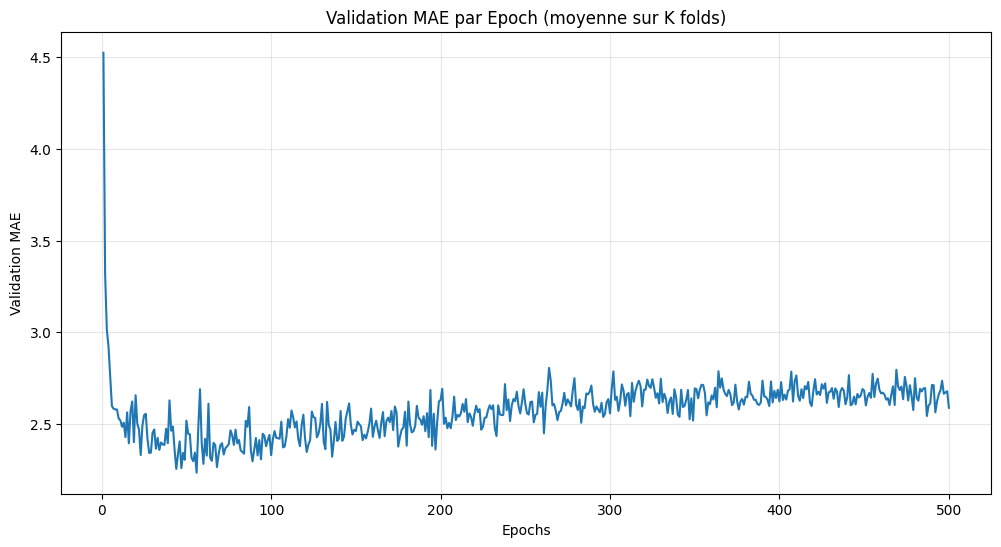

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(average_mae_history) + 1), average_mae_history)
plt.title('Validation MAE par Epoch (moyenne sur K folds)')
plt.xlabel('Epochs')
plt.ylabel('Validation MAE')
plt.grid(True, alpha=0.3)
plt.show()

## Exercice 9 — Lissage avec Exponential Moving Average

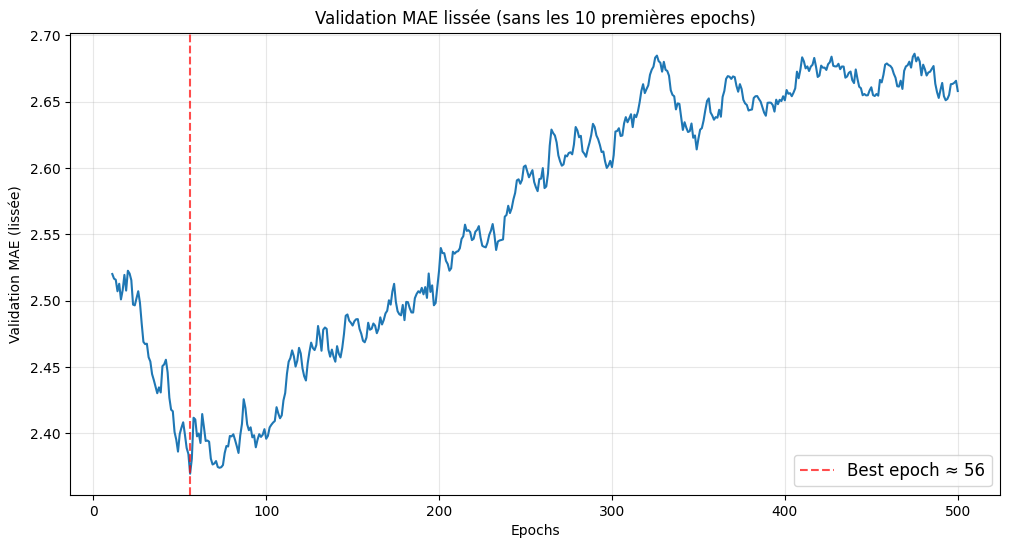

📊 Meilleure MAE lissée : 2.37 à l'epoch ~56
   → Après cette epoch, le modèle commence à overfitter.


In [ ]:
def smooth_curve(points, factor=0.9):
    """Lissage par moyenne mobile exponentielle.
    point = previous_point * factor + current_point * (1 - factor)"""
    smoothed_points = []
    for point in points:
        if smoothed_points:
            previous = smoothed_points[-1]
            smoothed_points.append(previous * factor + point * (1 - factor))
        else:
            smoothed_points.append(point)
    return smoothed_points

# On omet les 10 premiers points (échelle différente) et on lisse
smooth_mae = smooth_curve(average_mae_history[10:])

plt.figure(figsize=(12, 6))
plt.plot(range(10 + 1, len(smooth_mae) + 10 + 1), smooth_mae)
plt.title('Validation MAE lissée (sans les 10 premières epochs)')
plt.xlabel('Epochs')
plt.ylabel('Validation MAE (lissée)')
plt.grid(True, alpha=0.3)

# Marquer le point optimal
best_epoch = np.argmin(smooth_mae) + 11
best_mae = min(smooth_mae)
plt.axvline(x=best_epoch, color='r', linestyle='--', alpha=0.7, label=f'Best epoch ≈ {best_epoch}')
plt.legend(fontsize=12)
plt.show()

print(f"📊 Meilleure MAE lissée : {best_mae:.2f} à l'epoch ~{best_epoch}")
print(f"   → Après cette epoch, le modèle commence à overfitter.")

## Exercice 10 — Modèle final avec les meilleurs paramètres

In [ ]:
# Entraînement du modèle final sur TOUTES les données d'entraînement
# avec le nombre optimal d'epochs trouvé ci-dessus
optimal_epochs = best_epoch

final_model = build_model()
final_model.fit(train_data, train_targets,
                epochs=optimal_epochs,
                batch_size=16,
                verbose=0)

# Évaluation sur le test set
test_mse, test_mae = final_model.evaluate(test_data, test_targets, verbose=0)

print(f"=== Modèle Final (entraîné sur {optimal_epochs} epochs) ===")
print(f"Test MSE : {test_mse:.2f}")
print(f"Test MAE : {test_mae:.2f}")
print(f"→ Le modèle se trompe en moyenne de ~${test_mae*1000:.0f} sur le prix d'une maison")

=== Modèle Final (entraîné sur 56 epochs) ===
Test MSE : 18.62
Test MAE : 2.83
→ Le modèle se trompe en moyenne de ~$2831 sur le prix d'une maison


---
# 📝 Synthèse Générale — Techniques de Régularisation

| Technique | Principe | Quand l'utiliser |
|---|---|---|
| **Réduire la taille du modèle** | Moins de paramètres → moins de mémorisation | Premier réflexe si overfitting |
| **L1 Regularization** | Pénalise `|w|`, crée de la sparsité | Quand on veut sélectionner des features |
| **L2 Regularization** | Pénalise `w²`, garde les poids petits | Technique par défaut, très utilisée |
| **Dropout** | Désactive des neurones aléatoirement | Très efficace pour les couches denses |
| **Augmentation de données texte** | Crée des variantes des reviews pour enrichir le train set | Quand on manque de diversité de données |
| **Early Stopping** | Arrête l'entraînement avant l'overfitting | Toujours recommandé en pratique |
| **K-Fold Cross Validation** | Évaluation robuste sur peu de données | Quand le dataset est petit |
| **Plus de données** | La meilleure régularisation ! | Quand c'est possible |

**En pratique**, on combine souvent plusieurs techniques : par exemple **Dropout + augmentation de données + Early Stopping**.


# Partie 3: Optimisation

## Exercice 1 — Chargement du dataset Boston Housing

In [ ]:
from keras.datasets import boston_housing
import numpy as np

(bh_train_data, bh_train_targets), (bh_test_data, bh_test_targets) = boston_housing.load_data()

print("=== Dataset Boston Housing ===")
print(f"Train data shape   : {bh_train_data.shape}")
print(f"Test data shape    : {bh_test_data.shape}")
print(f"Train targets shape: {bh_train_targets.shape}")
print(f"Test targets shape : {bh_test_targets.shape}")

=== Dataset Boston Housing ===
Train data shape   : (404, 13)
Test data shape    : (102, 13)
Train targets shape: (404,)
Test targets shape : (102,)


## Exercice 2 — Normalisation des données

In [ ]:
mean = bh_train_data.mean(axis=0)
std = bh_train_data.std(axis=0)

bh_train_data = (bh_train_data - mean) / std
bh_test_data = (bh_test_data - mean) / std

print("Après normalisation :")
print(f"Train mean ≈ 0 : {bh_train_data.mean(axis=0)[:5].round(2)}")
print(f"Train std  ≈ 1 : {bh_train_data.std(axis=0)[:5].round(2)}")

Après normalisation :
Train mean ≈ 0 : [-0.  0.  0. -0. -0.]
Train std  ≈ 1 : [1. 1. 1. 1. 1.]


**Analyse :** La normalisation est essentielle car les features ont des échelles très différentes (taux de criminalité vs nombre de pièces vs taxe). Sans normalisation, le réseau aurait du mal à converger.

## Exercice 3 — Définition du modèle

In [ ]:
from tensorflow.keras import models, layers

def build_model(input_dim, optimizer='adam'):
    model = models.Sequential([
        layers.Dense(64, activation='relu', input_shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(1)
    ])
    model.compile(
        optimizer=optimizer,
        loss='mse',
        metrics=['mae']
    )
    return model

In [ ]:
sgd_model = build_model(input_dim=bh_train_data.shape[1], optimizer="sgd")

## Exercices 4 & 5 — K-Fold Cross Validation (K=4, 100 epochs)

In [ ]:
def run_kfold_for_optimizer(optimizer_name, x_train, y_train, k=4, num_epochs=200, batch_size=16):
    x_train = np.asarray(x_train, dtype='float32')
    y_train = np.asarray(y_train, dtype='float32')

    print(f"\nOptimizer = {optimizer_name}")
    print("x_train shape:", x_train.shape)
    print("y_train shape:", y_train.shape)

    assert len(x_train) == len(y_train), (
        f"Mismatch: len(x_train)={len(x_train)} vs len(y_train)={len(y_train)}"
    )

    num_val_samples = len(x_train) // k
    all_scores = []
    all_mae_histories = []

    for i in range(k):
        print(f'Processing fold #{i+1}/{k}')

        val_data = x_train[i * num_val_samples: (i + 1) * num_val_samples]
        val_targets = y_train[i * num_val_samples: (i + 1) * num_val_samples]

        partial_train_data = np.concatenate(
            [x_train[:i * num_val_samples], x_train[(i + 1) * num_val_samples:]],
            axis=0
        )
        partial_train_targets = np.concatenate(
            [y_train[:i * num_val_samples], y_train[(i + 1) * num_val_samples:]],
            axis=0
        )

        model = build_model(input_dim=x_train.shape[1], optimizer=optimizer_name)

        history = model.fit(
            partial_train_data,
            partial_train_targets,
            validation_data=(val_data, val_targets),
            epochs=num_epochs,
            batch_size=batch_size,
            verbose=0
        )

        val_mse, val_mae = model.evaluate(val_data, val_targets, verbose=0)
        all_scores.append(val_mae)
        all_mae_histories.append(history.history['val_mae'])

    average_mae_history = [
        np.mean([x[i] for x in all_mae_histories]) for i in range(num_epochs)
    ]

    return {
        "optimizer": optimizer_name,
        "fold_scores": all_scores,
        "average_mae_history": average_mae_history
    }

## Exercices 6 & 7 — K-Fold avec 500 epochs (sauvegarde MAE par epoch)

In [ ]:
optimizers_to_test = ['sgd', 'adagrad', 'rmsprop', 'adam']
results = {}

for opt in optimizers_to_test:
    results[opt] = run_kfold_for_optimizer(
        optimizer_name=opt,
        x_train=bh_train_data,
        y_train=bh_train_targets,
        k=4,
        num_epochs=200,
        batch_size=16
    )


Optimizer = sgd
x_train shape: (404, 13)
y_train shape: (404,)
Processing fold #1/4
Processing fold #2/4
Processing fold #3/4
Processing fold #4/4

Optimizer = adagrad
x_train shape: (404, 13)
y_train shape: (404,)
Processing fold #1/4
Processing fold #2/4
Processing fold #3/4
Processing fold #4/4

Optimizer = rmsprop
x_train shape: (404, 13)
y_train shape: (404,)
Processing fold #1/4
Processing fold #2/4
Processing fold #3/4
Processing fold #4/4

Optimizer = adam
x_train shape: (404, 13)
y_train shape: (404,)
Processing fold #1/4
Processing fold #2/4
Processing fold #3/4
Processing fold #4/4


## Exercice 8 — Plot MAE par epoch

In [ ]:
for opt, res in results.items():
    print(f"\n=== Résultats K-Fold pour {opt.upper()} ===")
    for i, score in enumerate(res["fold_scores"]):
        print(f"Fold {i+1} MAE : {score:.2f} (erreur moyenne de ${score*1000:.0f})")

    print(f"MAE moyenne : {np.mean(res['fold_scores']):.2f} (±{np.std(res['fold_scores']):.2f})")


=== Résultats K-Fold pour SGD ===
Fold 1 MAE : 1.94 (erreur moyenne de $1938)
Fold 2 MAE : 1.87 (erreur moyenne de $1866)
Fold 3 MAE : 2.28 (erreur moyenne de $2284)
Fold 4 MAE : nan (erreur moyenne de $nan)
MAE moyenne : nan (±nan)

=== Résultats K-Fold pour ADAGRAD ===
Fold 1 MAE : 4.16 (erreur moyenne de $4158)
Fold 2 MAE : 5.32 (erreur moyenne de $5316)
Fold 3 MAE : 4.64 (erreur moyenne de $4639)
Fold 4 MAE : 4.80 (erreur moyenne de $4800)
MAE moyenne : 4.73 (±0.41)

=== Résultats K-Fold pour RMSPROP ===
Fold 1 MAE : 2.03 (erreur moyenne de $2032)
Fold 2 MAE : 2.52 (erreur moyenne de $2515)
Fold 3 MAE : 2.38 (erreur moyenne de $2379)
Fold 4 MAE : 2.46 (erreur moyenne de $2464)
MAE moyenne : 2.35 (±0.19)

=== Résultats K-Fold pour ADAM ===
Fold 1 MAE : 2.14 (erreur moyenne de $2137)
Fold 2 MAE : 2.46 (erreur moyenne de $2462)
Fold 3 MAE : 2.39 (erreur moyenne de $2393)
Fold 4 MAE : 2.30 (erreur moyenne de $2298)
MAE moyenne : 2.32 (±0.12)


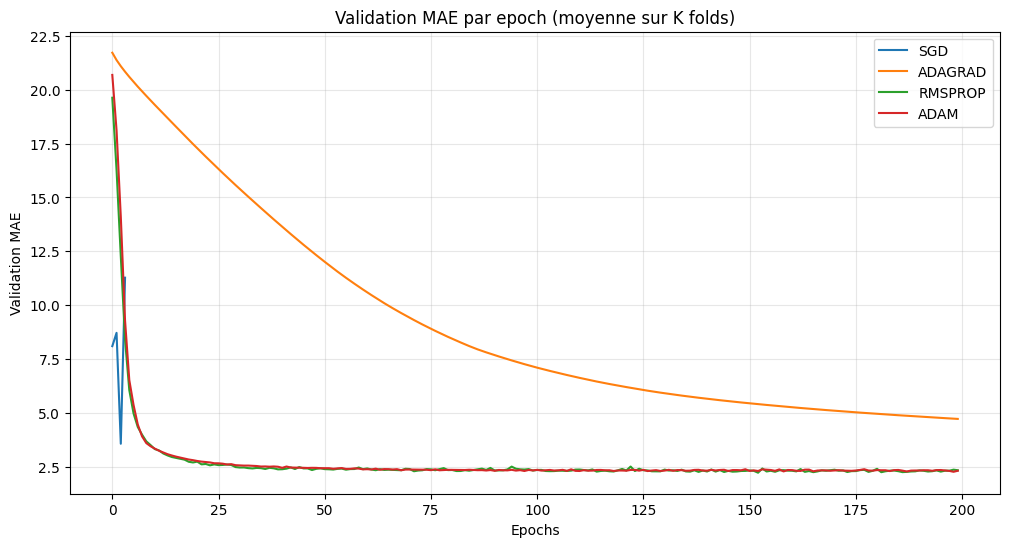

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
for opt, res in results.items():
    plt.plot(res["average_mae_history"], label=opt.upper())

plt.title("Validation MAE par epoch (moyenne sur K folds)")
plt.xlabel("Epochs")
plt.ylabel("Validation MAE")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Exercice 9 — Lissage avec Exponential Moving Average

In [ ]:
def smooth_curve(points, factor=0.9):
    smoothed_points = []
    for point in points:
        if smoothed_points:
            previous = smoothed_points[-1]
            smoothed_points.append(previous * factor + point * (1 - factor))
        else:
            smoothed_points.append(point)
    return smoothed_points

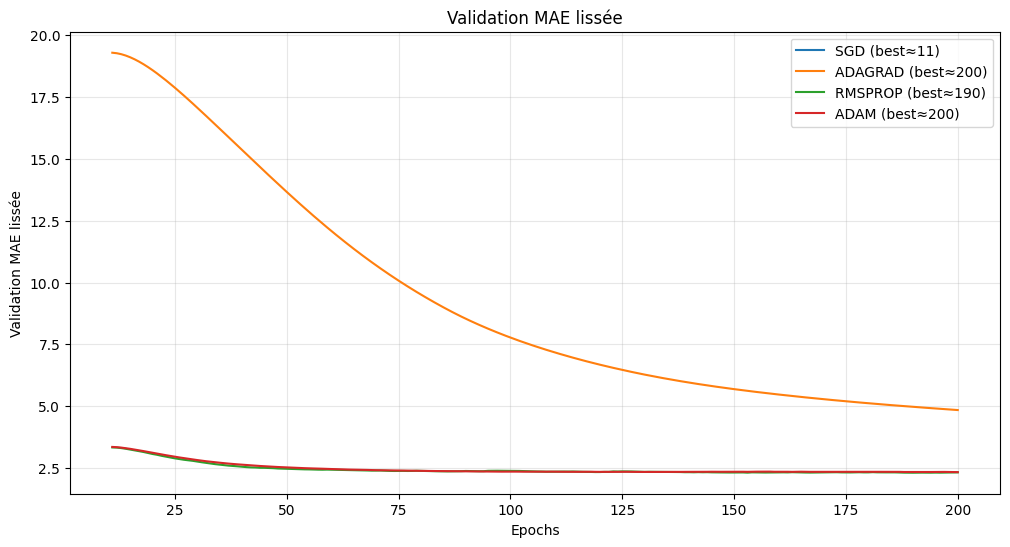

In [ ]:
smoothed_results = {}

plt.figure(figsize=(12, 6))

for opt, res in results.items():
    smooth_mae = smooth_curve(res["average_mae_history"][10:])
    best_epoch = np.argmin(smooth_mae) + 11
    best_mae = np.min(smooth_mae)

    smoothed_results[opt] = {
        "smooth_mae": smooth_mae,
        "best_epoch": best_epoch,
        "best_mae": best_mae
    }

    plt.plot(range(11, len(smooth_mae) + 11), smooth_mae, label=f"{opt.upper()} (best≈{best_epoch})")

plt.title("Validation MAE lissée")
plt.xlabel("Epochs")
plt.ylabel("Validation MAE lissée")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
print("\n=== Meilleures epochs par optimiseur ===")
for opt, res in smoothed_results.items():
    print(f"{opt.upper():8s} : meilleure MAE lissée = {res['best_mae']:.2f} à l'epoch ~{res['best_epoch']}")


=== Meilleures epochs par optimiseur ===
SGD      : meilleure MAE lissée = nan à l'epoch ~11
ADAGRAD  : meilleure MAE lissée = 4.84 à l'epoch ~200
RMSPROP  : meilleure MAE lissée = 2.31 à l'epoch ~190
ADAM     : meilleure MAE lissée = 2.33 à l'epoch ~200


## Exercice 10 — Modèle final avec le meilleur optimiseur

In [ ]:
final_test_results = {}

for opt in optimizers_to_test:
    optimal_epochs = smoothed_results[opt]["best_epoch"]

    final_model = build_model(input_dim=bh_train_data.shape[1], optimizer=opt)
    final_model.fit(
        bh_train_data,
        bh_train_targets,
        epochs=optimal_epochs,
        batch_size=16,
        verbose=0
    )

    test_mse, test_mae = final_model.evaluate(bh_test_data, bh_test_targets, verbose=0)

    final_test_results[opt] = {
        "optimal_epochs": optimal_epochs,
        "test_mse": test_mse,
        "test_mae": test_mae
    }

In [ ]:
print("\n=== Comparaison finale sur le test set ===")
for opt, res in final_test_results.items():
    print(f"{opt.upper():8s} | epochs={res['optimal_epochs']:3d} | Test MSE={res['test_mse']:.2f} | Test MAE={res['test_mae']:.2f}")


=== Comparaison finale sur le test set ===
SGD      | epochs= 11 | Test MSE=41.63 | Test MAE=4.53
ADAGRAD  | epochs=200 | Test MSE=30.29 | Test MAE=4.25
RMSPROP  | epochs=190 | Test MSE=16.65 | Test MAE=2.75
ADAM     | epochs=200 | Test MSE=14.04 | Test MAE=2.55


In [ ]:
sorted_models = sorted(final_test_results.items(), key=lambda x: x[1]["test_mae"])

print("\n=== Classement final (du meilleur au moins bon) ===")
for rank, (opt, res) in enumerate(sorted_models, start=1):
    print(f"{rank}. {opt.upper():8s} -> Test MAE = {res['test_mae']:.2f} (≈ ${res['test_mae']*1000:.0f})")


=== Classement final (du meilleur au moins bon) ===
1. ADAM     -> Test MAE = 2.55 (≈ $2552)
2. RMSPROP  -> Test MAE = 2.75 (≈ $2746)
3. ADAGRAD  -> Test MAE = 4.25 (≈ $4253)
4. SGD      -> Test MAE = 4.53 (≈ $4530)
